# Overall

```
- 프로젝트명 : Funnel Analysis
- 프로젝트유형 : 고객 행동 데이터 Funnel 데이터 분석
- 시나리오 : 비즈니스 의사 결정 위한 고객 행동 데이터 분석 수행
- 문제정의 : 매출 급감 여부 파악, 시기 특정, 이탈 단계 파악, 원인 파악, 카테고리 특정
- 기대효과 : 구체화된 문제 개선 통한 총 funnel 크기 및 매출 증대 도모
- 해결방안 : 시기를 특정, 원인 파악 위한 세부 분석 진행
- 성과측정 : 개선 액션 전후, 특정된 카테고리의 총 세션 수, event_type 지표 개선 수준 모니터링 수행

- 제안
    - category_code 'appliances.environment.vacuum' 의 views 감소가 29-31 기간 내 views 감소의 가장 높은 기여를 한 것으로 파악되었으며 해당 상품에 대한 대응을 최우선 검토 제안드립니다.

- 분석결과 상세
    - 일별 매출 추이 파악
        - 최고점 매출 기록 시기인 17-18 일자를 기준으로 매출 급감 기록 및 감소세 이어지고 있음을 확인하였습니다.
        - 증감세 추이 파악 시 감소세가 가장 높았던 일자로 19일 임을 파악할 수 있었습니다.
    - 일별 event_type, user_session 수 변화 추이 파악
        - 17일 이후 세션 전체 감소세를 보이는 점을 확인하였습니다.
    - 일별 event_type, user_session 수 변화 추이 파악 : 17-31 일자 세부 분석
        - event_type 비중 변화 기준 17-31 일자 cart, views 점진적 비중 증대되는 점을 확인하였습니다.
        - 29-31 일자 간 급격한 총 세션 수 감소세를 보이는 점을 파악하였으며, 주요 원인으로 view의 감소를  파악하였습니다.
    - views 감소 category_code 파악 : 29-31 일자 세부 분석
        - category_code 'appliances.environment.vacuum' 의 views 감소가 29-31 기간 내 views 감소의 가장 높은 기여를 한 것으로 파악되었으며 해당 상품에 대한 대응을 최우선 검토 제안드립니다.

- Meta data
    - event_time : 이벤트가 발생한 시간
    - event_type : 이벤트 유형 (view, cart, remove_from_cart, purchase 중 하나)
    - product_id : 제품 ID
    - category_id : 제품 카테고리 ID
    - category_code : 의미 있는 카테고리 이름 (존재하는 경우)
    - brand : 브랜드 이름 (소문자, 존재하는 경우)
    - price : 제품 가격
    - user_id : 영구 사용자 ID
    - user_session : 사용자 세션 ID
```

<!--
https://colab.research.google.com/drive/18x_RhKrPgufeAyhu6HHnfY7shYuU42A9#scrollTo=jR4fX00ayV2m&uniqifier=1
https://colab.research.google.com/drive/1DB-gaPpPNj3JMuQpAbqrYg4HJUWA07u6#scrollTo=QoMmLoBq7oBn
 -->

# Data Import / Libraries

In [ ]:
#Warnings 제거
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# columns
pd.set_option('display.max_columns',100)

# ## 색상 변경
# plt.style.use(['dark_background'])

## 한글 깨짐 현상 방지
%pip install koreanize_matplotlib
import koreanize_matplotlib

## 과학표기법을 숫자로 변경하는 과정
pd.options.display.float_format = '{:.2f}'.format


In [ ]:
# Data import
import pandas as pd
df = pd.read_csv('P_PJT11_DATA.csv')
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-12-01 00:00:00 UTC,remove_from_cart,5712790,1487580005268456287,NaN,f.o.x,6.27,576802932,51d85cb0-897f-48d2-918b-ad63965c12dc
1,2019-12-01 00:00:00 UTC,view,5764655,1487580005411062629,NaN,cnd,29.05,412120092,8adff31e-2051-4894-9758-224bfa8aec18
2,2019-12-01 00:00:02 UTC,cart,4958,1487580009471148064,NaN,runail,1.19,494077766,c99a50e8-2fac-4c4d-89ec-41c05f114554
3,2019-12-01 00:00:05 UTC,view,5848413,1487580007675986893,NaN,freedecor,0.79,348405118,722ffea5-73c0-4924-8e8f-371ff8031af4
4,2019-12-01 00:00:07 UTC,view,5824148,1487580005511725929,NaN,NaN,5.56,576005683,28172809-7e4a-45ce-bab0-5efa90117cd5


In [ ]:
# need to event_time > to_datetime
# info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3533286 entries, 0 to 3533285
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     object 
 1   event_type     object 
 2   product_id     int64  
 3   category_id    int64  
 4   category_code  object 
 5   brand          object 
 6   price          float64
 7   user_id        int64  
 8   user_session   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 242.6+ MB


In [ ]:
# na
# category_code	3474821
# brand	1510289
# user_session	779
df.isna().sum()

,0
event_time,0
event_type,0
product_id,0
category_id,0
category_code,3474821
brand,1510289
price,0
user_id,0
user_session,779


In [ ]:
df.nunique()

,0
event_time,1654771
event_type,4
product_id,44624
category_id,482
category_code,10
brand,252
price,2122
user_id,370154
user_session,839812


In [ ]:
# change str to dt format / event_time > to_datetime
df['event_time'] = pd.to_datetime(df['event_time'])

In [ ]:
df['event_time'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 3533286 entries, 0 to 3533285
Series name: event_time
Non-Null Count    Dtype              
--------------    -----              
3533286 non-null  datetime64[ns, UTC]
dtypes: datetime64[ns, UTC](1)
memory usage: 27.0 MB


In [ ]:
# date duration
df['event_time'].min(), df['event_time'].max()

(Timestamp('2019-12-01 00:00:00+0000', tz='UTC'),
 Timestamp('2019-12-31 23:59:57+0000', tz='UTC'))

# preprocessing


In [ ]:
# comparison between raw df category_code na value included and exlcuded

In [ ]:
# raw
display(df.describe())
display(df.info())
display(df.shape)
display(df.isna().sum())

,product_id,category_id,price,user_id
count,3533286.00,3533286.00,3533286.00,3533286.00
mean,5473053.80,1555023012945680128.00,8.87,522331835.07
std,1331331.39,168926187070693152.00,19.86,84948189.60
min,3752.00,1487580004807082752.00,-79.37,1180452.00
25%,5726191.00,1487580006300255232.00,2.06,486682994.00
50%,5811429.00,1487580008447738880.00,4.21,556649586.00
75%,5859462.00,1487580013581566208.00,7.14,582801855.00
max,5917178.00,2235524499636224256.00,327.78,595414541.00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3533286 entries, 0 to 3533285
Data columns (total 9 columns):
 #   Column         Dtype              
---  ------         -----              
 0   event_time     datetime64[ns, UTC]
 1   event_type     object             
 2   product_id     int64              
 3   category_id    int64              
 4   category_code  object             
 5   brand          object             
 6   price          float64            
 7   user_id        int64              
 8   user_session   object             
dtypes: datetime64[ns, UTC](1), float64(1), int64(3), object(4)
memory usage: 242.6+ MB


None

(3533286, 9)

,0
event_time,0
event_type,0
product_id,0
category_id,0
category_code,3474821
brand,1510289
price,0
user_id,0
user_session,779


In [ ]:
# except na data
tmp = df[~df['category_code'].isna() & ~df['brand'].isna() & ~df['user_session'].isna()]
display(tmp.describe())
display(tmp.info())
display(tmp.shape)
display(tmp.isna().sum())

,product_id,category_id,price,user_id
count,43193.00,43193.00,43193.00,43193.00
mean,5529116.93,1608894465318251776.00,36.01,524918289.75
std,1300012.28,238469267505315296.00,33.17,82376174.41
min,5395.00,1487580006350586880.00,0.68,15400971.00
25%,5775814.00,1487580006350586880.00,4.16,490115847.00
50%,5855507.00,1487580006350586880.00,24.60,557921512.00
75%,5873430.00,1487580013053083904.00,62.70,583096962.00
max,5915788.00,2193074740686488320.00,150.79,595404548.00


<class 'pandas.core.frame.DataFrame'>
Index: 43193 entries, 33 to 3533226
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   event_time     43193 non-null  datetime64[ns, UTC]
 1   event_type     43193 non-null  object             
 2   product_id     43193 non-null  int64              
 3   category_id    43193 non-null  int64              
 4   category_code  43193 non-null  object             
 5   brand          43193 non-null  object             
 6   price          43193 non-null  float64            
 7   user_id        43193 non-null  int64              
 8   user_session   43193 non-null  object             
dtypes: datetime64[ns, UTC](1), float64(1), int64(3), object(4)
memory usage: 3.3+ MB


None

(43193, 9)

,0
event_time,0
event_type,0
product_id,0
category_id,0
category_code,0
brand,0
price,0
user_id,0
user_session,0


In [ ]:
# as of volume of raw data is so big, try to proceed with data that na values excluded.
# will check again if volume is small than expected.
df_final = df[~df['category_code'].isna() & ~df['brand'].isna() & ~df['user_session'].isna()].copy()

In [ ]:
# seperate datetime to details
df_final['month'] = df_final['event_time'].dt.month
df_final['day'] = df_final['event_time'].dt.day
df_final['hour'] = df_final['event_time'].dt.hour
df_final

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,month,day,hour
33,2019-12-01 00:01:47+00:00,view,5732026,1487580011970953351,furniture.bathroom.bath,domix,4.16,509445281,91e9d610-759a-4831-b89a-22f2ab5fbc0f,12,1,0
52,2019-12-01 00:02:42+00:00,view,5746846,2193074740686488401,furniture.bathroom.bath,irisk,52.70,579970581,0b92a801-25d8-4da5-b514-fda26db3faae,12,1,0
90,2019-12-01 00:03:48+00:00,view,5884577,1487580006350586771,appliances.environment.vacuum,max,47.46,499259978,4ee80bbb-17cb-447d-9188-9aa306db3481,12,1,0
112,2019-12-01 00:04:19+00:00,view,5855507,1487580006350586771,appliances.environment.vacuum,max,79.21,499259978,4ee80bbb-17cb-447d-9188-9aa306db3481,12,1,0
138,2019-12-01 00:05:14+00:00,view,5884578,1487580006350586771,appliances.environment.vacuum,max,63.33,499259978,4ee80bbb-17cb-447d-9188-9aa306db3481,12,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
3532871,2019-12-31 23:16:21+00:00,view,5771614,2193074740619379535,furniture.living_room.cabinet,kosmekka,150.79,573455420,2bf92988-a105-41a3-94bc-6b9887378cf3,12,31,23
3532874,2019-12-31 23:17:05+00:00,view,5771614,2193074740619379535,furniture.living_room.cabinet,kosmekka,150.79,573455420,2bf92988-a105-41a3-94bc-6b9887378cf3,12,31,23
3533061,2019-12-31 23:37:22+00:00,view,5854574,1487580006350586771,appliances.environment.vacuum,jessnail,21.43,400986985,0218e750-c3d0-474a-993f-c1aa98b43941,12,31,23
3533221,2019-12-31 23:54:19+00:00,view,5854573,1487580006350586771,appliances.environment.vacuum,jessnail,46.83,584900297,191a4251-e99c-4dc9-87ee-295107387d58,12,31,23


In [ ]:
df_final.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,month,day,hour
33,2019-12-01 00:01:47+00:00,view,5732026,1487580011970953351,furniture.bathroom.bath,domix,4.16,509445281,91e9d610-759a-4831-b89a-22f2ab5fbc0f,12,1,0
52,2019-12-01 00:02:42+00:00,view,5746846,2193074740686488401,furniture.bathroom.bath,irisk,52.70,579970581,0b92a801-25d8-4da5-b514-fda26db3faae,12,1,0
90,2019-12-01 00:03:48+00:00,view,5884577,1487580006350586771,appliances.environment.vacuum,max,47.46,499259978,4ee80bbb-17cb-447d-9188-9aa306db3481,12,1,0
112,2019-12-01 00:04:19+00:00,view,5855507,1487580006350586771,appliances.environment.vacuum,max,79.21,499259978,4ee80bbb-17cb-447d-9188-9aa306db3481,12,1,0
138,2019-12-01 00:05:14+00:00,view,5884578,1487580006350586771,appliances.environment.vacuum,max,63.33,499259978,4ee80bbb-17cb-447d-9188-9aa306db3481,12,1,0


# Analysis

## 일별 매출 추이 파악

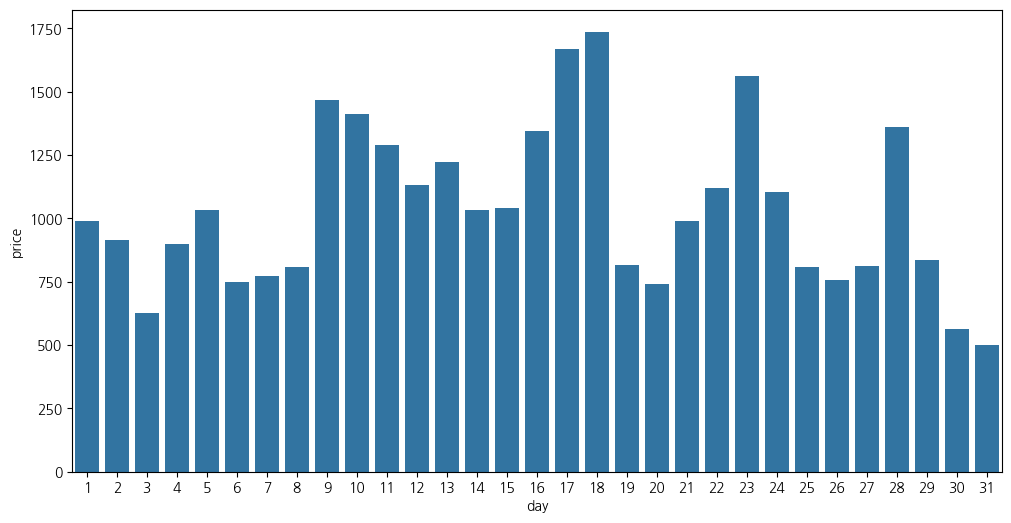

In [ ]:
## 최고점 매출 기록 시기인 17-18 일자를 기준으로 매출 급감 기록 및 감소세 이어지고 있음을 확인

## purchase 데이터만 sort
tmp = df_final[df_final['event_type'] == 'purchase']

plt.figure(figsize = (12, 6))
sns.barplot(tmp.groupby('day')['price'].agg('sum'))
plt.show()

# price 에 0 데이터는 없습니다.
# tmp[tmp['price'] <= 0]

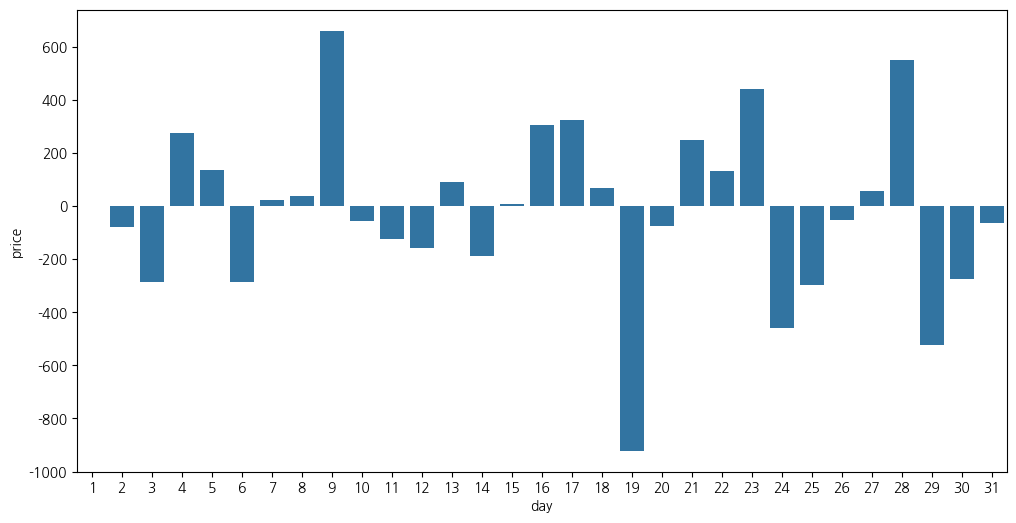

In [ ]:
# 증감세 추이 파악 시 감소세가 가장 높았던 일자로 19일 임을 파악할 수 있었습니다.
plt.figure(figsize = (12, 6))
sns.barplot(tmp.groupby('day')['price'].agg('sum').diff())
plt.show()


## 일별 event_type, user_session 수 변화 추이 파악

In [ ]:
dfgr = df_final.groupby(['day','event_type'])['user_session'].size().reset_index()
dfgr.columns = ['day', 'event_type', 'count']
dfgr.head()

,day,event_type,count
0,1,cart,254
1,1,purchase,53
2,1,remove_from_cart,158
3,1,view,1199
4,2,cart,303


In [ ]:
dfgr_pivot = dfgr.pivot(index='day', columns='event_type', values='count').reset_index()
dfgr_pivot.head()

event_type,day,cart,purchase,remove_from_cart,view
0,1,254,53,158,1199
1,2,303,66,234,1219
2,3,245,73,153,1217
3,4,436,70,212,1160
4,5,306,80,173,1136


<Figure size 1400x600 with 0 Axes>

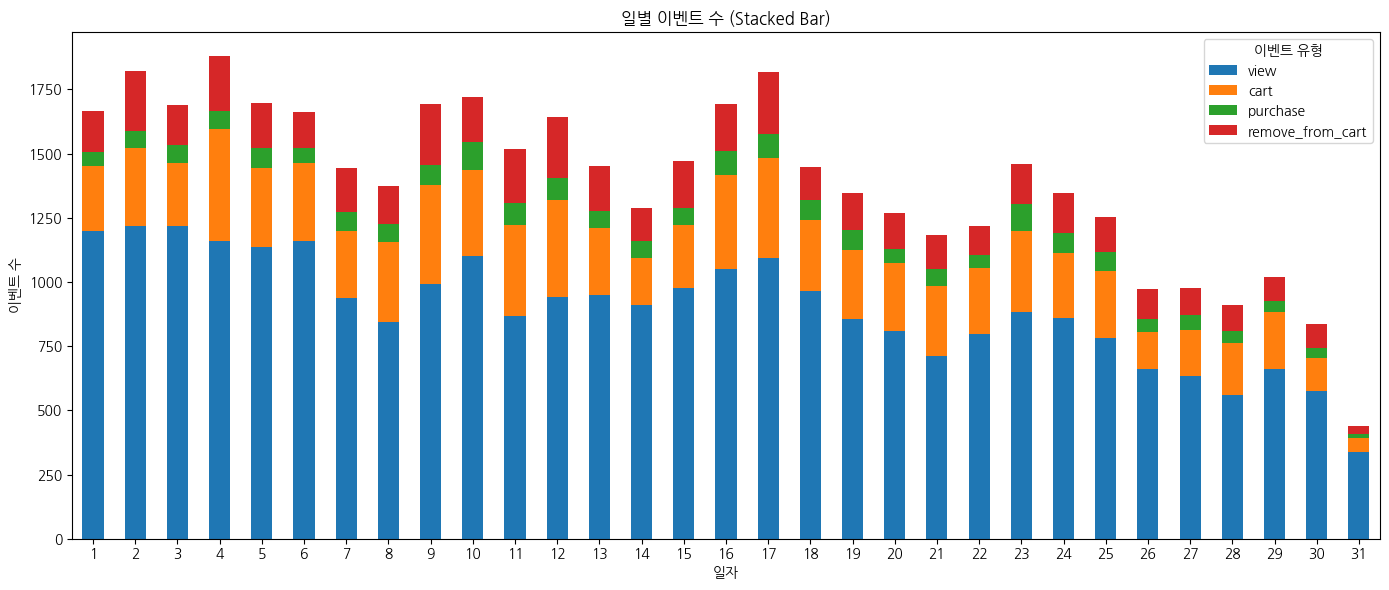

In [ ]:
# 17일 이후 세션 전체 감소세를 보이는 점을 확인하였습니다.
# 17일 부터 각 세션별 비중 변화 등을 추가적으로 분석 진행하겠습니다.

import pandas as pd
import matplotlib.pyplot as plt

# 1. day를 인덱스로 설정
df_plot = dfgr_pivot.set_index('day')

# 2. 시각화 대상 컬럼만 선택 (view, cart, purchase, remove_from_cart 순서)
df_plot = df_plot[['view', 'cart', 'purchase', 'remove_from_cart']]

# 3. Stacked bar chart 그리기
plt.figure(figsize=(14, 6))
df_plot.plot(kind='bar', stacked=True, figsize=(14, 6))

# 그래프 커스터마이징
plt.title("일별 이벤트 수 (Stacked Bar)")
plt.xlabel("일자")
plt.ylabel("이벤트 수")
plt.legend(title='이벤트 유형')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
df_plot['total'] = df_plot.sum(axis=1)
df_plot.T.style.background_gradient(cmap='coolwarm')

day,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31
event_type,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
view,1199,1219,1217,1160,1136,1158,936,842,991,1102,867,942,951,910,977,1051,1093,963,854,810,713,799,884,860,781,660,634,561,660,575,337
cart,254,303,245,436,306,304,264,314,385,333,353,377,260,185,243,366,390,279,270,262,273,256,314,253,261,145,180,202,224,130,54
purchase,53,66,73,70,80,58,71,71,80,108,88,84,67,63,67,91,92,76,78,57,63,51,105,76,75,49,58,47,41,36,17
remove_from_cart,158,234,153,212,173,141,171,147,235,178,210,240,174,129,182,186,243,129,144,141,134,111,157,156,135,118,104,102,95,96,31
total,1664,1822,1688,1878,1695,1661,1442,1374,1691,1721,1518,1643,1452,1287,1469,1694,1818,1447,1346,1270,1183,1217,1460,1345,1252,972,976,912,1020,837,439


## 일별 event_type, user_session 수 변화 추이 파악 : 17-31 일자 세부 분석

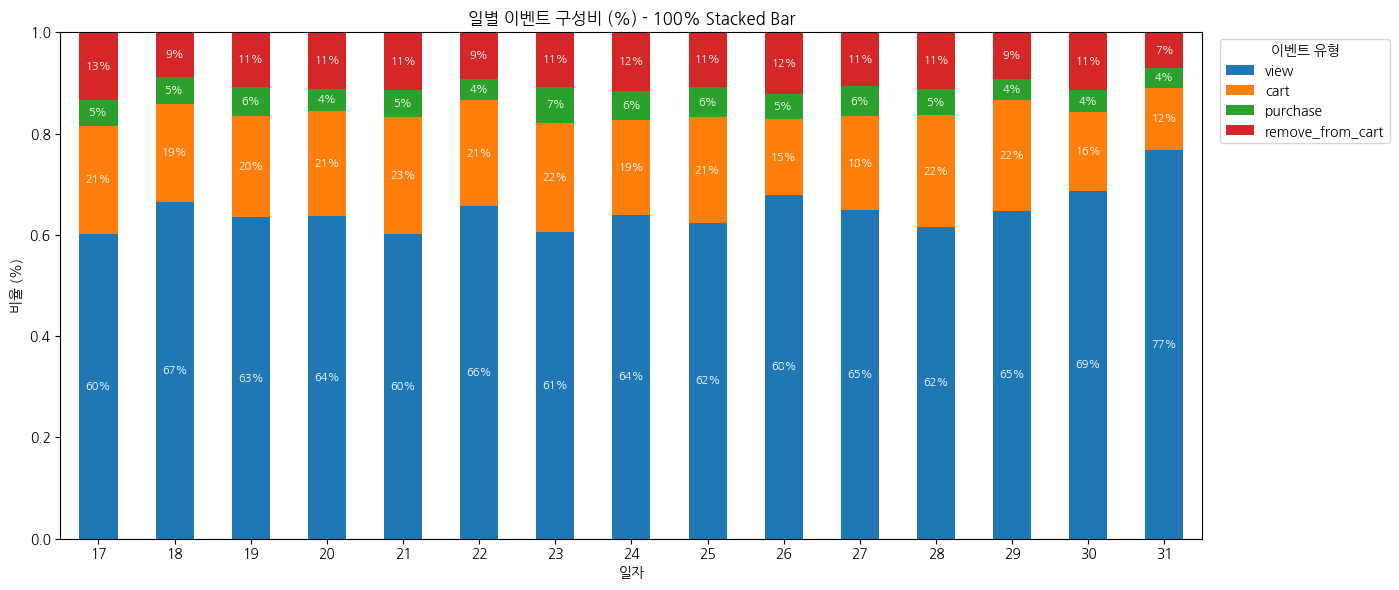

In [ ]:
# day between 17 and 31

import matplotlib.pyplot as plt

# 1. day를 인덱스로 설정
df_plot = dfgr_pivot[dfgr_pivot['day'] >= 17].set_index('day')

# 2. 시각화 대상 컬럼만 선택
df_plot = df_plot[['view', 'cart', 'purchase', 'remove_from_cart']]

# 3. 비율 계산 (100% 기준)
df_percent = df_plot.div(df_plot.sum(axis=1), axis=0)

# 4. Plot
fig, ax = plt.subplots(figsize=(14, 6))
df_percent.plot(kind='bar', stacked=True, ax=ax)

# 5. % 데이터 레이블 추가
for i, (idx, row) in enumerate(df_percent.iterrows()):
    cum_height = 0
    for col in df_percent.columns:
        height = row[col]
        if height > 0.03:  # 너무 작으면 생략
            ax.text(i, cum_height + height / 2, f'{height:.0%}', ha='center', va='center', fontsize=8, color='white')
        cum_height += height

# 6. 커스터마이징
ax.set_title("일별 이벤트 구성비 (%) - 100% Stacked Bar")
ax.set_xlabel("일자")
ax.set_ylabel("비율 (%)")
ax.legend(title='이벤트 유형', loc='upper right', bbox_to_anchor=(1.17, 1))
ax.set_ylim(0, 1)
ax.set_xticks(range(len(df_percent)))
ax.set_xticklabels(df_percent.index, rotation=0)

plt.tight_layout()
plt.show()


In [ ]:
df_percent.T.style.background_gradient(cmap='coolwarm')

day,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31
event_type,,,,,,,,,,,,,,,
view,0.601210,0.665515,0.634473,0.637795,0.602705,0.656532,0.605479,0.639405,0.623802,0.679012,0.649590,0.615132,0.647059,0.686977,0.767654
cart,0.214521,0.192813,0.200594,0.206299,0.230769,0.210353,0.215068,0.188104,0.208466,0.149177,0.184426,0.221491,0.219608,0.155317,0.123007
purchase,0.050605,0.052522,0.057949,0.044882,0.053254,0.041906,0.071918,0.056506,0.059904,0.050412,0.059426,0.051535,0.040196,0.043011,0.038724
remove_from_cart,0.133663,0.089150,0.106984,0.111024,0.113271,0.091208,0.107534,0.115985,0.107827,0.121399,0.106557,0.111842,0.093137,0.114695,0.070615


<Figure size 1400x600 with 0 Axes>

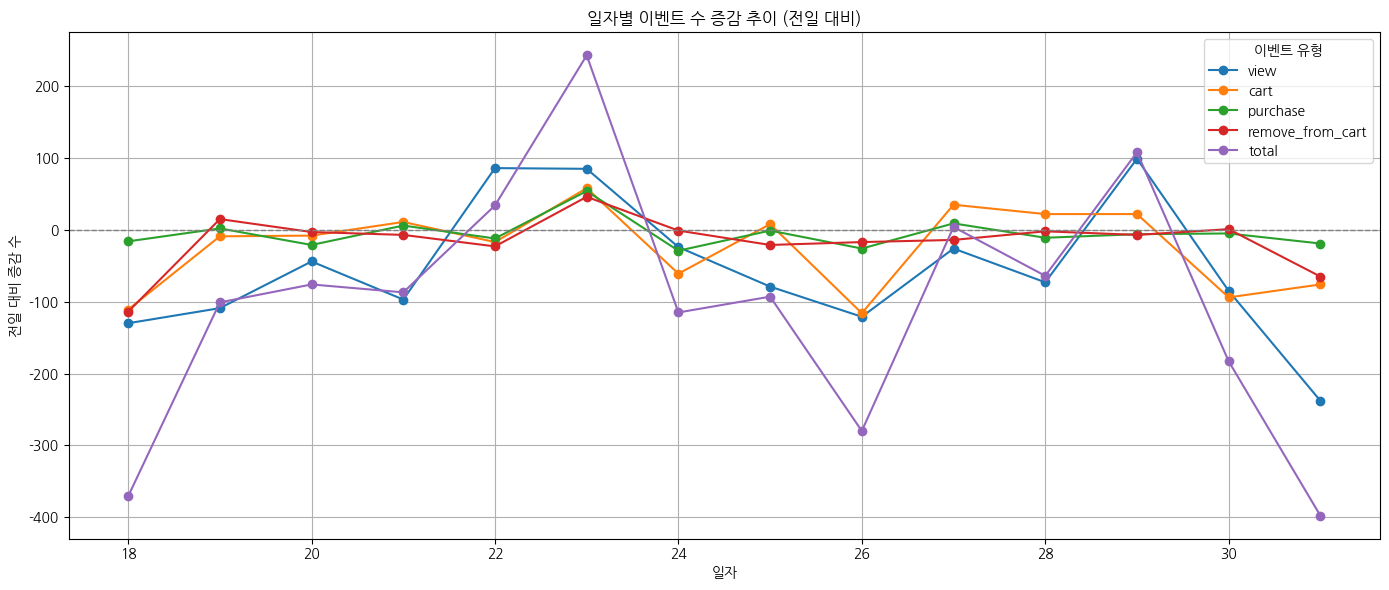

In [ ]:
# 29-31 일자 간 급격한 총 세션 수 감소세를 보이는 점을 파악하였으며, 주요 원인으로 view의 감소를  파악하였습니다.
# 최우선 개선 목표를 view metric 으로 설정, 29-31 기간 view 변화 추이 분석 수행하겠습니다.

# 변동(차이) 계산: 각 컬럼의 하루 전 대비 증감량

# total column 추가
df_plot['total'] = df_plot.sum(axis=1)

df_diff = df_plot.diff()

# 그래프 그리기
plt.figure(figsize=(14, 6))
df_diff[['view', 'cart', 'purchase', 'remove_from_cart', 'total']].plot(
    kind='line',
    marker='o',
    figsize=(14, 6)
)

plt.title("일자별 이벤트 수 증감 추이 (전일 대비)")
plt.xlabel("일자")
plt.ylabel("전일 대비 증감 수")
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.legend(title='이벤트 유형')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_diff.style.background_gradient(cmap='coolwarm')

event_type,view,cart,purchase,remove_from_cart,total
day,,,,,
17,nan,nan,nan,nan,nan
18,-130.000000,-111.000000,-16.000000,-114.000000,-742.000000
19,-109.000000,-9.000000,2.000000,15.000000,-202.000000
20,-44.000000,-8.000000,-21.000000,-3.000000,-152.000000
21,-97.000000,11.000000,6.000000,-7.000000,-174.000000
22,86.000000,-17.000000,-12.000000,-23.000000,68.000000
23,85.000000,58.000000,54.000000,46.000000,486.000000
24,-24.000000,-61.000000,-29.000000,-1.000000,-230.000000
25,-79.000000,8.000000,-1.000000,-21.000000,-186.000000


## views 감소 category_code 파악 : 29-31 일자 세부 분석

In [ ]:
# category_code 'appliances.environment.vacuum' 의 views 감소가 해당 기간 내 views 감소의 가장 높은 기여를 한 것으로 파악되었으며 해당 상품에 대한 대응을 최우선 검토 제안드립니다.
tmp = df_final[df_final['day'] >= 29].groupby(['day', 'event_type', 'category_code'])['user_session'].count().reset_index()
tmp = tmp[tmp['event_type'] == 'view'].sort_values(by = ['day', 'category_code'], ascending = [True, False])

tmp.pivot(index='category_code', columns='day', values='user_session').reset_index().sort_values(by =29, ascending = False).style.background_gradient(cmap='coolwarm')


day,category_code,29,30,31
4,appliances.environment.vacuum,361.000000,439.000000,242.000000
8,stationery.cartrige,114.000000,50.000000,33.000000
2,apparel.glove,68.000000,32.000000,23.000000
0,accessories.bag,39.000000,12.000000,3.000000
7,furniture.living_room.cabinet,34.000000,20.000000,17.000000
6,furniture.bathroom.bath,29.000000,16.000000,16.000000
1,accessories.cosmetic_bag,9.000000,4.000000,2.000000
5,appliances.personal.hair_cutter,5.000000,2.000000,1.000000
3,appliances.environment.air_conditioner,1.000000,nan,nan


In [ ]:
tmp = tmp.pivot(index='category_code', columns='day', values='user_session')
tmp.diff().reset_index().sort_values(by =29, ascending = True).style.background_gradient(cmap='coolwarm')


day,category_code,29,30,31
5,appliances.personal.hair_cutter,-356.000000,-437.000000,-241.000000
3,appliances.environment.air_conditioner,-67.000000,nan,nan
1,accessories.cosmetic_bag,-30.000000,-8.000000,-1.000000
7,furniture.living_room.cabinet,5.000000,4.000000,1.000000
6,furniture.bathroom.bath,24.000000,14.000000,15.000000
2,apparel.glove,59.000000,28.000000,21.000000
8,stationery.cartrige,80.000000,30.000000,16.000000
4,appliances.environment.vacuum,360.000000,nan,nan
0,accessories.bag,nan,nan,nan


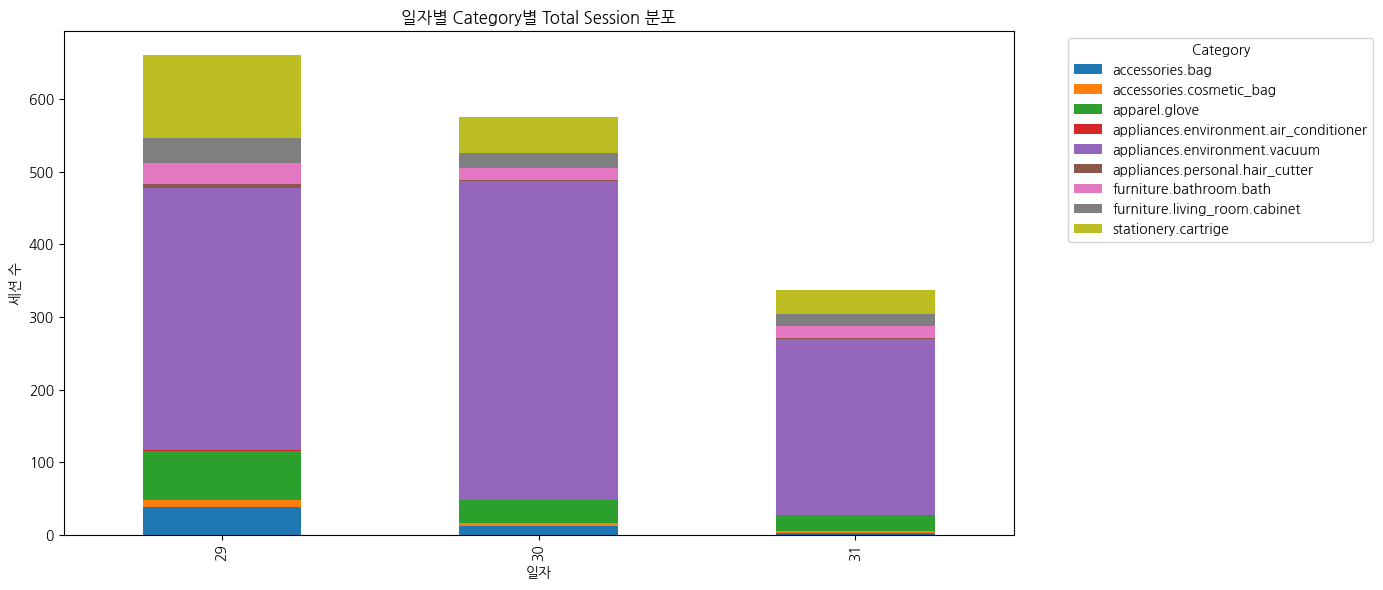

In [ ]:
# stacked bar plot
tmp = df_final[df_final['day'] >= 29].groupby(['day', 'event_type', 'category_code'])['user_session'].count().reset_index()
tmp = tmp[tmp['event_type'] == 'view'].sort_values(by = ['day', 'category_code'], ascending = [True, False])
pivot_df = tmp.pivot(index='day', columns='category_code', values='user_session').fillna(0)

pivot_df.plot(kind='bar', stacked=True, figsize=(14, 6))

plt.title("일자별 Category별 Total Session 분포")
plt.xlabel("일자")
plt.ylabel("세션 수")
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()